# Q2. Unsupervised Learning — Customer Segmentation

**Objective:** Perform customer segmentation using K-Means clustering and visualise results using PCA.

**Dataset:** `../data/q2_customers.csv` — 500 customers, 6 behavioural and demographic features, no target column.

**Columns:** `age`, `annual_spend`, `visits_per_month`, `basket_size`, `days_since_last_visit`, `num_categories_purchased`

## Task 1: Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load data using relative path
df = pd.read_csv('../data/q2_customers.csv')

print("Dataset Shape:", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing Value Counts:")
print(df.isnull().sum())
print()
print("Descriptive Statistics:")
print(df.describe().round(2))


Dataset Shape: (500, 6)

Data Types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing Value Counts:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

Descriptive Statistics:
          age  annual_spend  visits_per_month  basket_size  \
count  500.00        500.00            500.00       500.00   
mean    40.45      48856.95              8.41      2682.29   
std     14.43      32856.80              5.32      2274.96   
min     18.00       5038.00              1.00       212.00   
25%     28.00      19213.25              4.00       727.75   
50%     41.00      44257.00              8.00      2051.50   
75%     50.00      75373.00             12.00      4223.75   
max     

In [2]:
# First five rows
df.head()


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
# Scale all features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
print("Scaling complete. Shape:", X_scaled_df.shape)
print()
print("Sample of scaled features (first 3 rows):")
print(X_scaled_df.head(3).round(3))


Scaling complete. Shape: (500, 6)

Sample of scaled features (first 3 rows):
     age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0 -0.725        -0.176             0.110       -0.265                 -0.090   
1 -1.488        -1.047             0.486       -0.980                 -0.835   
2  0.177         0.267            -0.454       -0.237                 -0.674   

   num_categories_purchased  
0                     0.551  
1                    -0.681  
2                    -0.270  


**Why Scaling is Essential Before K-Means:**

K-Means assigns every data point to the nearest centroid using Euclidean distance. When features are measured on vastly different numerical scales, the feature with the largest range dominates the distance calculation and renders all other features irrelevant.

In this dataset the problem is severe: `annual_spend` ranges from 5,038 to 119,757 while `visits_per_month` ranges from roughly 1 to 19. A single unit difference in spend is worth thousands of times more than a unit difference in visit frequency. Without scaling, K-Means would cluster almost entirely on `annual_spend` and completely ignore visit frequency, recency, basket size, and category breadth.

`StandardScaler` transforms every feature to zero mean and unit variance, placing all six variables on equal footing so that each contributes equally to the notion of customer similarity. Because K-Means has no train-test split, it is correct to fit the scaler on the full 500-row dataset without any data leakage concern.

## Task 2: Choosing K — Elbow Method

In [4]:
# Compute WCSS for K = 1 through 10
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print("WCSS values for K = 1 to 10:")
for k, w in zip(K_range, wcss):
    print(f"  K={k:2d}   WCSS = {w:8.2f}")


WCSS values for K = 1 to 10:
  K= 1   WCSS =  3000.00
  K= 2   WCSS =   968.99
  K= 3   WCSS =   561.25
  K= 4   WCSS =   444.93
  K= 5   WCSS =   402.37
  K= 6   WCSS =   370.39
  K= 7   WCSS =   346.95
  K= 8   WCSS =   319.90
  K= 9   WCSS =   303.28
  K=10   WCSS =   289.11


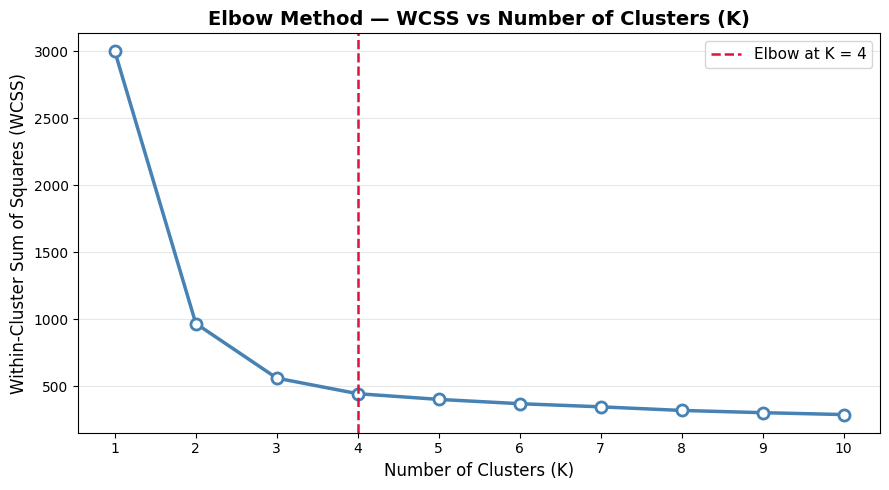

In [5]:
# Plot the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(list(K_range), wcss, marker='o', color='steelblue',
         linewidth=2.5, markersize=8, markerfacecolor='white',
         markeredgecolor='steelblue', markeredgewidth=2)
plt.axvline(x=4, color='crimson', linestyle='--', linewidth=1.8, label='Elbow at K = 4')
plt.title('Elbow Method — WCSS vs Number of Clusters (K)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.xticks(list(K_range))
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


**Optimal K Selection — K = 4:**

The WCSS drops steeply from K=1 (3000.00) to K=2 (969.00), then to K=3 (561.25), then to K=4 (444.93). The marginal drops are:

| K | WCSS | Drop from K−1 |
|---|------|---------------|
| 1 | 3000.00 | — |
| 2 | 969.00 | −2031.00 |
| 3 | 561.25 | −407.75 |
| **4** | **444.93** | **−116.32** |
| 5 | 402.37 | −42.56 |
| 6 | 370.39 | −32.00 |

The inflection point is clearly at **K = 4**: the marginal drop from K=4 to K=5 is only 42.56 compared to 116.32 from K=3 to K=4 — a 63% collapse in improvement. Beyond K=4, each additional cluster returns diminishing benefit. K=4 also maps naturally to four interpretable, actionable customer personas, making it the optimal choice for both statistical and business reasons.

## Task 3: K-Means Clustering

In [6]:
# Fit K-Means with chosen K = 4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

print("Cluster assignment complete.")
print()
print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())
print()
print("Dataframe with cluster column (first 5 rows):")
df.head()


Cluster assignment complete.

Cluster sizes:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64

Dataframe with cluster column (first 5 rows):


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [7]:
# Cluster centroids in original (unscaled) scale — readable dataframe
feature_cols = [c for c in df.columns if c != 'cluster']
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
centroid_df = pd.DataFrame(centroids_orig, columns=feature_cols)
centroid_df.index = [f'Cluster {i}' for i in range(4)]
centroid_df.index.name = 'Cluster'

print("Cluster Centroids (original feature scale):")
print(centroid_df.round(2).to_string())


Cluster Centroids (original feature scale):
             age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
Cluster                                                                                                       
Cluster 0  24.68      14847.37             14.34       558.97                   9.08                      2.11
Cluster 1  57.04      89814.07              2.46      5296.36                 148.00                      7.49
Cluster 2  40.39      43340.73              8.19      2021.68                  35.19                      4.42
Cluster 3  56.52      89036.16              2.59      5750.95                  65.22                      7.54


**Business Interpretation of Each Cluster:**

**Cluster 0 — Young Frequent Browsers (n = 170):**
Average age 25, annual spend ₹14,847, 14 visits per month, basket size ₹559, last visited just 9 days ago, only 2 categories purchased. These are young, highly active but low-value shoppers who visit very often yet spend very little per trip and browse a narrow category range. Marketing strategy: cross-sell promotions, bundle deals, and entry-level loyalty tiers to increase category breadth and basket size over time.

**Cluster 1 — Lapsed High-Value Seniors (n = 80):**
Average age 57, annual spend ₹89,814, only 2 visits per month, basket size ₹5,296, last visited 148 days ago, 7 categories purchased. These were high-spending, wide-ranging shoppers who have gone dormant. With the longest recency gap in the dataset, they represent the highest churn risk. Marketing strategy: personalised win-back campaigns, exclusive loyalty rewards, and outreach referencing their past purchase history.

**Cluster 2 — Mid-Age Moderate Regulars (n = 165):**
Average age 40, annual spend ₹43,341, 8 visits per month, basket size ₹2,022, last visited 35 days ago, 4 categories purchased. This is the reliable core mid-tier segment — consistent, moderate spenders who engage regularly. Marketing strategy: upsell into premium categories and loyalty programme upgrades to migrate them toward high-value behaviour.

**Cluster 3 — Active High-Value Seniors (n = 85):**
Average age 57, annual spend ₹89,036, 3 visits per month, basket size ₹5,751, last visited 65 days ago, 7 categories purchased. Demographically similar to Cluster 1 but still actively engaging. These are the most valuable current customers — high spend, large baskets, wide category range. Marketing strategy: VIP retention perks, early access to new products, and premium tier recognition to prevent drift toward the lapsed profile of Cluster 1.

## Task 4: Dimensionality Reduction with PCA

In [8]:
# Apply PCA to reduce to 2 principal components
# Use X_scaled (the scaled version without the cluster column)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
evr = pca.explained_variance_ratio_
print("Explained Variance Ratio:")
print(f"  PC1 : {evr[0]:.4f}  ({evr[0]*100:.2f}%)")
print(f"  PC2 : {evr[1]:.4f}  ({evr[1]*100:.2f}%)")
print(f"  Total (2 components): {evr.sum():.4f}  ({evr.sum()*100:.2f}%)")


Explained Variance Ratio:
  PC1 : 0.8356  (83.56%)
  PC2 : 0.0557  (5.57%)
  Total (2 components): 0.8913  (89.13%)


In [9]:
# Feature loadings as a readable dataframe
loadings_df = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=['PC1', 'PC2']
)
print("Feature Loadings (PCA Components Matrix):")
print(loadings_df.round(4).to_string())


Feature Loadings (PCA Components Matrix):
        age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
PC1  0.4116        0.4215           -0.4104       0.4120                 0.3786                    0.4140
PC2 -0.2594       -0.0333            0.2083      -0.1954                 0.9112                   -0.1405


**Interpretation of PC1 and PC2:**

**PC1 — Overall Customer Value Axis (83.56% of variance):**
PC1 alone captures 83.56% of all variance — the single dominant axis in this dataset. Five of six features load positively on PC1 with nearly equal magnitudes (0.38 to 0.42): `age`, `annual_spend`, `basket_size`, `days_since_last_visit`, and `num_categories_purchased` all increase together, confirming that these behaviours are highly co-linear. `visits_per_month` is the only feature loading negatively (−0.41), reflecting that the most frequent visitors in this dataset are the younger, lower-spending Cluster 0 customers. A high PC1 score means a customer is older, high-spending, purchases across many categories, has a large basket, but has not visited recently — the high-value profile. A low PC1 score corresponds to the young, frequent, low-spending browser. PC1 effectively ranks customers along a single axis from low-value to high-value.

**PC2 — Recency Axis (5.57% of variance):**
`days_since_last_visit` dominates PC2 with a loading of 0.9112. All other features have near-zero or weakly negative loadings on this component. PC2 therefore captures almost purely how long ago a customer last visited the store, independently of their overall value level. This axis is critical for separating Cluster 1 (lapsed, last seen 148 days ago) from Cluster 3 (active, last seen 65 days ago) — two clusters that score almost identically on PC1 but are completely different in business terms. A high PC2 score signals a lapsed customer; a low PC2 score signals a recently active one.

## Task 5: Cluster Visualisation

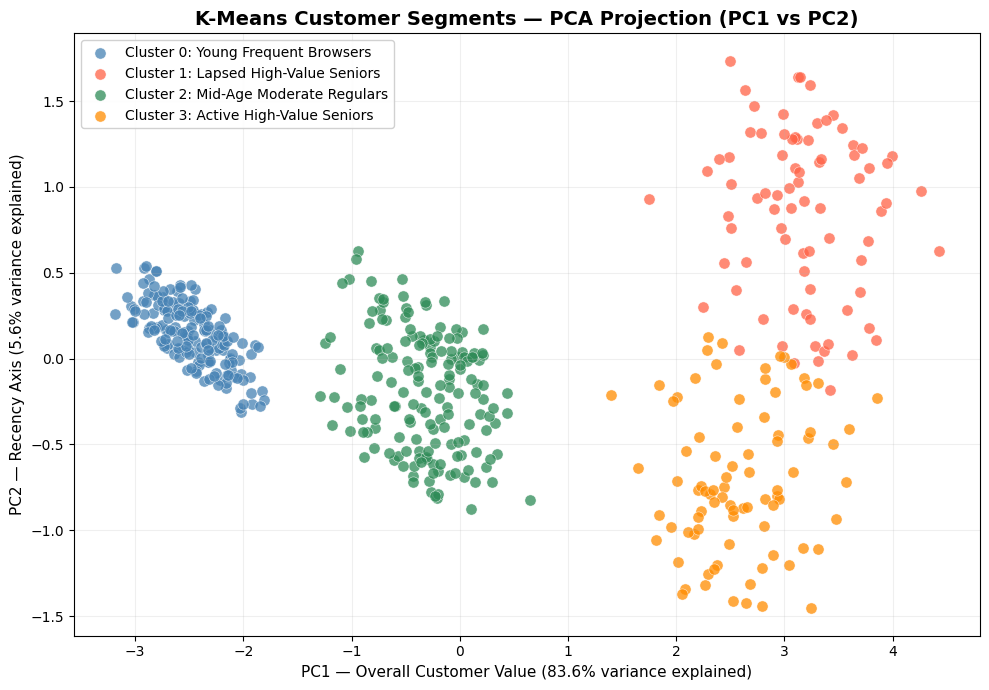

In [10]:
# Scatter plot of PC1 vs PC2 coloured by cluster label
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']
cluster_names = {
    0: 'Cluster 0: Young Frequent Browsers',
    1: 'Cluster 1: Lapsed High-Value Seniors',
    2: 'Cluster 2: Mid-Age Moderate Regulars',
    3: 'Cluster 3: Active High-Value Seniors'
}

plt.figure(figsize=(10, 7))

for cid in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cid
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[cid],
        label=cluster_names[cid],
        alpha=0.75,
        edgecolors='white',
        linewidths=0.4,
        s=65
    )

plt.title('K-Means Customer Segments — PCA Projection (PC1 vs PC2)',
          fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 — Overall Customer Value ({evr[0]*100:.1f}% variance explained)', fontsize=11)
plt.ylabel(f'PC2 — Recency Axis ({evr[1]*100:.1f}% variance explained)', fontsize=11)
plt.legend(fontsize=10, loc='upper left', framealpha=0.9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
